In [2]:
# Tiêu đề: Phân tích Lan tỏa và Biến động cấu trúc theo Trạng thái (Regime-Dependent Spillover Analysis).

# Mục tiêu:

# Tính toán thống kê có điều kiện (Conditional Statistics) cho từng Coin trong Bull vs Bear.

# Kiểm định sự thay đổi của Ma trận tương quan (Correlation Asymmetry).

# Thực hiện kiểm định Jennrich để xác nhận ý nghĩa thống kê.

In [3]:
import os

current_dir = os.getcwd()
print(current_dir)
os.chdir("..")
print(os.getcwd())


/Users/giangluong/Desktop/MasterDS/Thesis/LuongThiGiang_Thesis_Code/notebooks
/Users/giangluong/Desktop/MasterDS/Thesis/LuongThiGiang_Thesis_Code


In [4]:

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

import seaborn as sns
from scipy.stats import chi2


In [5]:
returns_file = Path("data/processed") / "log_returns_1d.csv"
regime_file = Path("data/processed") / "btc_regimes.csv"

# 1) Load log-returns Altcoins
df_returns = pd.read_csv(returns_file, parse_dates=["date"])
df_returns = df_returns.set_index("date").sort_index()

# 2) Load BTC regimes
df_regime = pd.read_csv(regime_file, parse_dates=["date"])
df_regime = df_regime.set_index("date").sort_index()

# Chỉ giữ cột BTC Log_Return + Regime_Combined
df_regime = df_regime.rename(columns={"Log_Return": "BTC_Log_Return"})
df_regime = df_regime[["BTC_Log_Return", "Regime_Combined"]]

# 3) Merge theo index (inner để chỉ giữ ngày có đủ cả 2 loại dữ liệu)
df_full = df_returns.join(df_regime, how="inner")

# Xóa các dòng không có Regime
df_full = df_full.dropna(subset=["Regime_Combined"])

# Lấy danh sách coin (các cột log-return altcoin)
asset_cols = [c for c in df_returns.columns]

# 4) Tách Bull / Bear theo Regime_Combined
df_bull = df_full[df_full["Regime_Combined"] == 1].drop(columns=["Regime_Combined"])
df_bear = df_full[df_full["Regime_Combined"] == 0].drop(columns=["Regime_Combined"])

print("Shape full:", df_full.shape)
print("Bull days:", df_bull.shape[0])
print("Bear days:", df_bear.shape[0])

df_full.head()


Shape full: (1834, 22)
Bull days: 1484
Bear days: 350


,ADA_USDT,ATOM_USDT,AVAX_USDT,BCH_USDT,BNB_USDT,BTC_USDT,DOGE_USDT,DOT_USDT,EOS_USDT,ETC_USDT,...,LTC_USDT,NEO_USDT,SOL_USDT,TRX_USDT,UNI_USDT,XLM_USDT,XRP_USDT,XTZ_USDT,BTC_Log_Return,Regime_Combined
date,,,,,,,,,,,,,,,,,,,,,
2020-09-23 00:00:00+00:00,-0.061123,-0.092251,-0.408628,-0.056597,-0.051791,-0.027747,-0.038095,-0.037898,-0.051666,-0.022412,...,-0.034545,-0.026073,-0.018533,-0.005216,0.113383,-0.061427,-0.050070,-0.075891,-0.027747,1
2020-09-24 00:00:00+00:00,0.074294,0.155081,0.272238,0.038903,0.073498,0.047188,0.032975,0.088420,0.036740,0.027152,...,0.044614,0.102649,0.096271,0.054406,0.164663,0.043974,0.048953,0.098414,0.047188,1
2020-09-25 00:00:00+00:00,0.160706,0.066447,0.015458,0.001387,0.004786,-0.004635,0.026937,0.008121,0.004253,0.001689,...,0.024193,-0.023283,0.015907,0.033343,-0.049521,0.058459,0.037027,0.025109,-0.004635,1
2020-09-26 00:00:00+00:00,-0.015177,-0.039162,-0.041898,0.021927,0.059256,0.003916,-0.001593,-0.019006,0.008219,0.074488,...,0.000217,-0.014510,-0.020563,0.001473,-0.009425,-0.011042,-0.000041,-0.018219,0.003916,1
2020-09-27 00:00:00+00:00,0.059274,0.025714,0.028011,0.035552,0.001952,0.004246,-0.000668,-0.008021,0.009389,0.015158,...,0.000434,0.006785,0.009258,-0.021946,-0.004653,-0.006794,0.007466,0.003129,0.004246,1


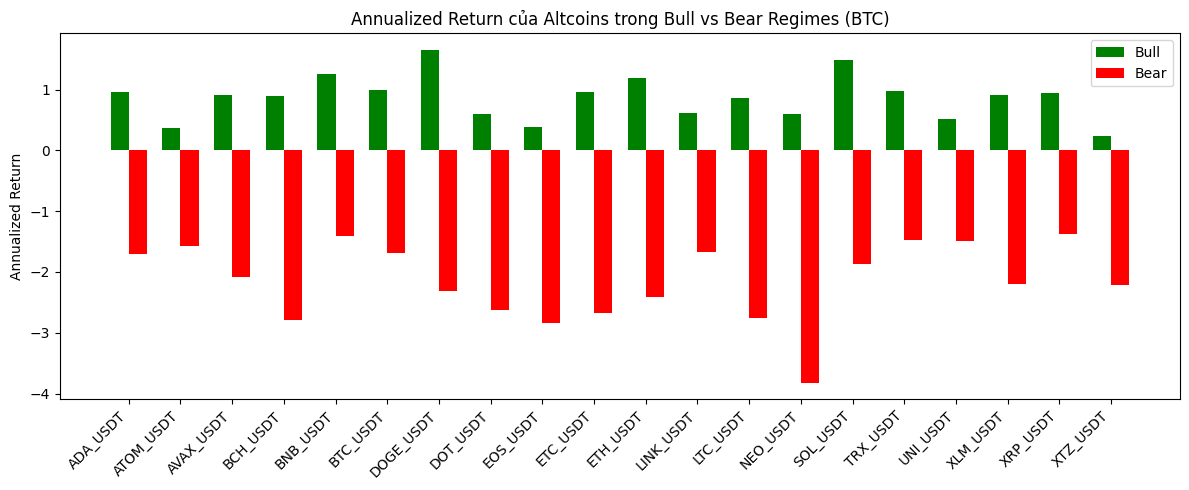

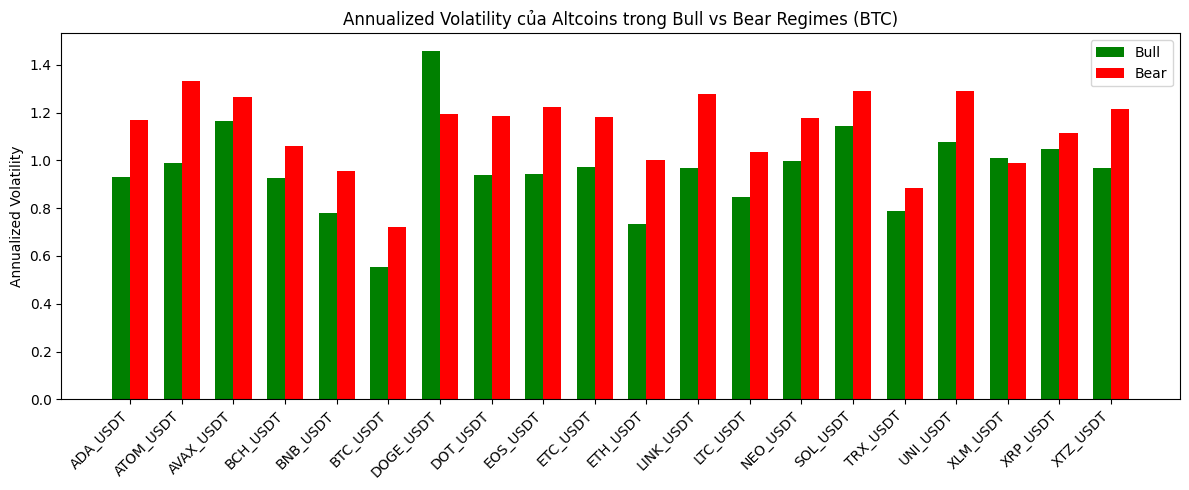

           Sharpe_Bull  Sharpe_Bear
ADA_USDT      0.054347    -0.076555
ATOM_USDT     0.019294    -0.062025
AVAX_USDT     0.041134    -0.086059
BCH_USDT      0.050173    -0.138258
BNB_USDT      0.083858    -0.076864
BTC_USDT      0.092846    -0.123052
DOGE_USDT     0.059178    -0.101871
DOT_USDT      0.033631    -0.115668
EOS_USDT      0.020865    -0.121329
ETC_USDT      0.051431    -0.118364
ETH_USDT      0.084458    -0.126187
LINK_USDT     0.033038    -0.068213
LTC_USDT      0.053348    -0.139068
NEO_USDT      0.031181    -0.169792
SOL_USDT      0.068310    -0.075681
TRX_USDT      0.065447    -0.086878
UNI_USDT      0.025079    -0.060599
XLM_USDT      0.047475    -0.116311
XRP_USDT      0.046979    -0.064482
XTZ_USDT      0.013062    -0.095664
           Mean_ann_Bull  Mean_ann_Bear
ADA_USDT        0.966864      -1.707752
ATOM_USDT       0.365246      -1.576253
AVAX_USDT       0.916704      -2.082486
BCH_USDT        0.889723      -2.797337
BNB_USDT        1.249586      -1.401894
BTC_

In [6]:
# Mô tả thống kê có điều kiện theo 2 pha Bull Bear đối với 20 coins

# Subset chỉ altcoin returns
bull_returns = df_bull[asset_cols]
bear_returns = df_bear[asset_cols]

# Daily stats
mean_bull_daily = bull_returns.mean()
std_bull_daily = bull_returns.std()

mean_bear_daily = bear_returns.mean()
std_bear_daily = bear_returns.std()

# Annualize (365 ngày giao dịch/năm)
TRADING_DAYS = 365

mean_bull_ann = mean_bull_daily * TRADING_DAYS
mean_bear_ann = mean_bear_daily * TRADING_DAYS

std_bull_ann = std_bull_daily * np.sqrt(TRADING_DAYS)
std_bear_ann = std_bear_daily * np.sqrt(TRADING_DAYS)

# Sharpe Ratio (daily, R_f = 0) – annual hóa chỉ là scale giống nhau
sharpe_bull = mean_bull_daily / std_bull_daily
sharpe_bear = mean_bear_daily / std_bear_daily

# ========== Plot 1: Annualized Return Bull vs Bear ==========
x = np.arange(len(asset_cols))
width = 0.35

fig, ax = plt.subplots(figsize=(12, 5))
ax.bar(x - width/2, mean_bull_ann[asset_cols], width, label="Bull", color="green")
ax.bar(x + width/2, mean_bear_ann[asset_cols], width, label="Bear", color="red")

ax.set_xticks(x)
ax.set_xticklabels(asset_cols, rotation=45, ha="right")
ax.set_ylabel("Annualized Return")
ax.set_title("Annualized Return của Altcoins trong Bull vs Bear Regimes (BTC)")
ax.legend()
plt.tight_layout()
plt.show()

# ========== Plot 2: Annualized Volatility Bull vs Bear ==========
fig, ax = plt.subplots(figsize=(12, 5))
ax.bar(x - width/2, std_bull_ann[asset_cols], width, label="Bull", color="green")
ax.bar(x + width/2, std_bear_ann[asset_cols], width, label="Bear", color="red")

ax.set_xticks(x)
ax.set_xticklabels(asset_cols, rotation=45, ha="right")
ax.set_ylabel("Annualized Volatility")
ax.set_title("Annualized Volatility của Altcoins trong Bull vs Bear Regimes (BTC)")
ax.legend()
plt.tight_layout()
plt.show()

sharpe_df = pd.DataFrame({
    "Sharpe_Bull": sharpe_bull,
    "Sharpe_Bear": sharpe_bear
})
print(sharpe_df)

mean_df = pd.DataFrame({
    "Mean_ann_Bull": mean_bull_ann,
    "Mean_ann_Bear": mean_bear_ann
})
print(mean_df)

std_df = pd.DataFrame({
    "std_Bull": std_bull_ann,
    "std_Bear": std_bear_ann
})
print(std_df)




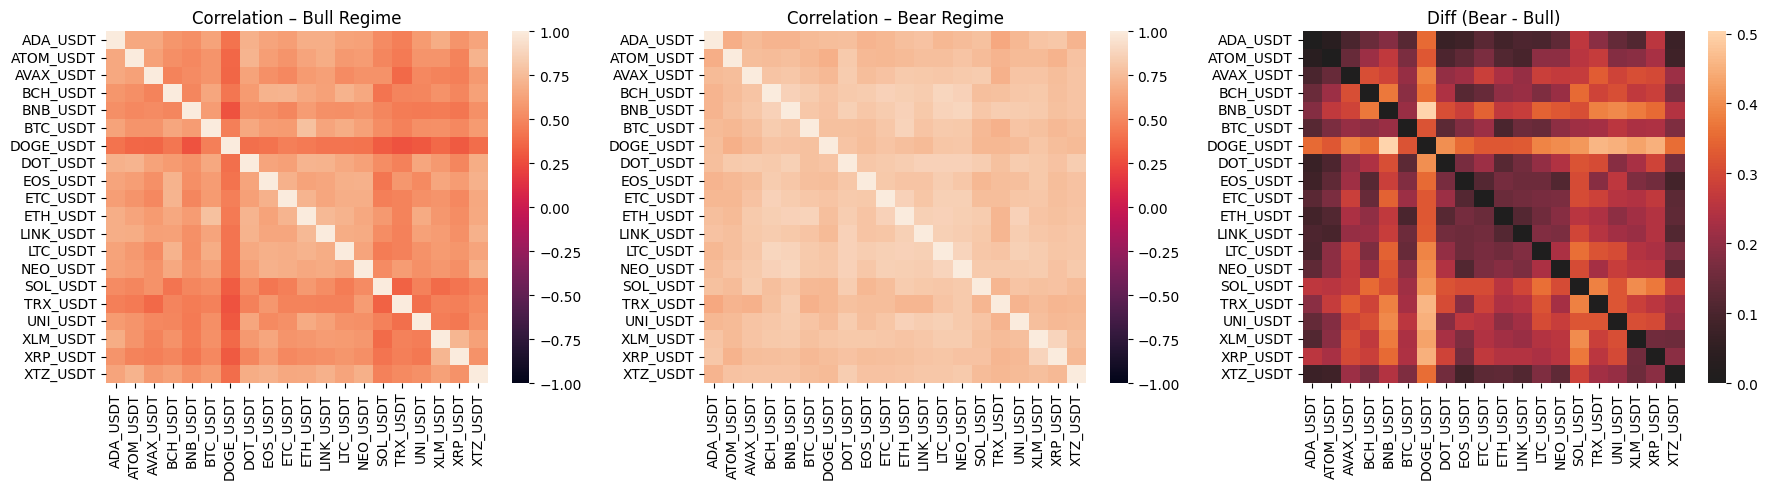

In [7]:
# Conditional correlation (Bull vs Bear) + Heatmaps

corr_bull = bull_returns.corr()
corr_bear = bear_returns.corr()
corr_diff = corr_bear - corr_bull  # Bear - Bull

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

sns.heatmap(corr_bull, ax=axes[0], vmin=-1, vmax=1, annot=False)
axes[0].set_title("Correlation – Bull Regime")

sns.heatmap(corr_bear, ax=axes[1], vmin=-1, vmax=1, annot=False)
axes[1].set_title("Correlation – Bear Regime")

sns.heatmap(corr_diff, ax=axes[2], center=0, annot=False)
axes[2].set_title("Diff (Bear - Bull)")

plt.tight_layout()
plt.show()


In [8]:
# Jennrich-style test (Average Correlation + Frobenius Distance)

def jennrich_test(df1: pd.DataFrame, df2: pd.DataFrame):
    """
    Thực hiện "Jennrich-lite" cho 2 ma trận tương quan.
    - df1: dữ liệu Bull
    - df2: dữ liệu Bear
    Trả về: avg_corr_bull, avg_corr_bear, frobenius_distance
    """
    # Số biến
    p = df1.shape[1]
    R1 = df1.corr().values
    R2 = df2.corr().values

    # Average correlation (bỏ đường chéo 1)
    avg_corr_1 = (R1.sum() - p) / (p * (p - 1))
    avg_corr_2 = (R2.sum() - p) / (p * (p - 1))

    diff = R2 - R1
    frob_norm = np.linalg.norm(diff)

    print(f"Average Correlation (Bull): {avg_corr_1:.4f}")
    print(f"Average Correlation (Bear): {avg_corr_2:.4f}")
    print(f"Frobenius Distance (Bear - Bull): {frob_norm:.4f}")

    return avg_corr_1, avg_corr_2, frob_norm

avg_corr_bull, avg_corr_bear, frob_dist = jennrich_test(bull_returns, bear_returns)


Average Correlation (Bull): 0.5551
Average Correlation (Bear): 0.7905
Frobenius Distance (Bear - Bull): 4.9166


In [9]:
#  Beta analysis – Beta của từng Altcoin với BTC trong Bull vs Bear

# BTC returns (log-return) từ df_full
btc_ret_full = df_full["BTC_Log_Return"]

# Align với bull / bear
btc_ret_bull = btc_ret_full.loc[df_bull.index]
btc_ret_bear = btc_ret_full.loc[df_bear.index]

beta_bull = {}
beta_bear = {}

for asset in asset_cols:
    r_i_bull = bull_returns[asset]
    r_i_bear = bear_returns[asset]

    # Cov / Var 
    common_bull = pd.concat([r_i_bull, btc_ret_bull], axis=1).dropna()
    common_bear = pd.concat([r_i_bear, btc_ret_bear], axis=1).dropna()

    if len(common_bull) > 1 and common_bull.iloc[:, 1].var() > 0:
        cov_bull = common_bull.iloc[:, 0].cov(common_bull.iloc[:, 1])
        var_btc_bull = common_bull.iloc[:, 1].var()
        beta_bull[asset] = cov_bull / var_btc_bull
    else:
        beta_bull[asset] = np.nan

    if len(common_bear) > 1 and common_bear.iloc[:, 1].var() > 0:
        cov_bear = common_bear.iloc[:, 0].cov(common_bear.iloc[:, 1])
        var_btc_bear = common_bear.iloc[:, 1].var()
        beta_bear[asset] = cov_bear / var_btc_bear
    else:
        beta_bear[asset] = np.nan

beta_df = pd.DataFrame({
    "Beta_Bull": pd.Series(beta_bull),
    "Beta_Bear": pd.Series(beta_bear)
})
beta_df


,Beta_Bull,Beta_Bear
ADA_USDT,1.050338,1.208093
ATOM_USDT,0.993979,1.342670
AVAX_USDT,1.171498,1.346940
BCH_USDT,1.071907,1.220944
BNB_USDT,0.835501,1.069554
BTC_USDT,1.000000,1.000000
DOGE_USDT,1.211294,1.289198
DOT_USDT,1.105114,1.285822
EOS_USDT,1.011557,1.313436
ETC_USDT,1.032445,1.321777


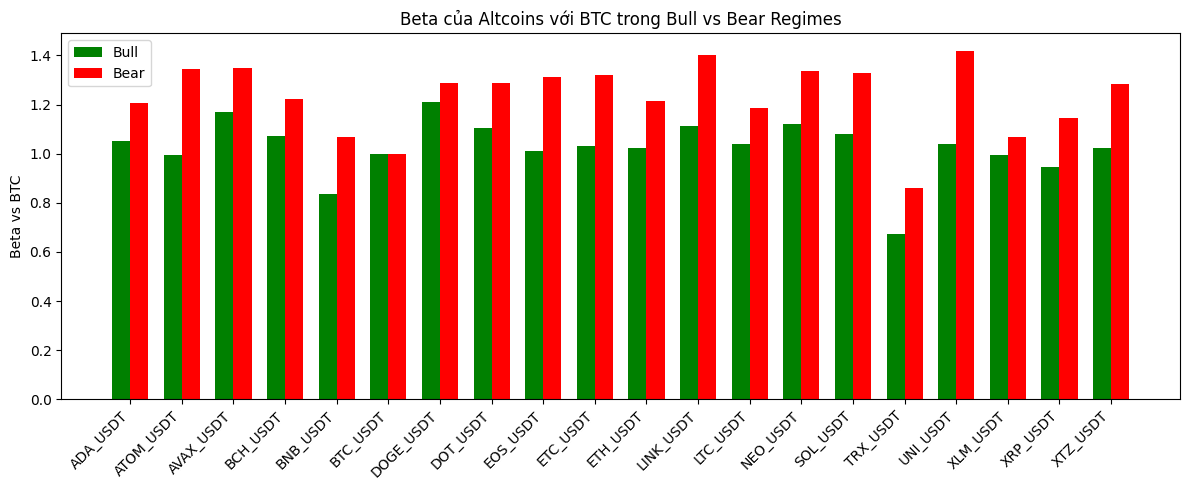

In [10]:
#  Plot Beta Bull vs Bear
# βi​=Var(rBTC​)Cov(ri​,rBTC​)​

x = np.arange(len(asset_cols))
width = 0.35

fig, ax = plt.subplots(figsize=(12, 5))
ax.bar(x - width/2, beta_df.loc[asset_cols, "Beta_Bull"], width, label="Bull", color="green")
ax.bar(x + width/2, beta_df.loc[asset_cols, "Beta_Bear"], width, label="Bear", color="red")

ax.set_xticks(x)
ax.set_xticklabels(asset_cols, rotation=45, ha="right")
ax.set_ylabel("Beta vs BTC")
ax.set_title("Beta của Altcoins với BTC trong Bull vs Bear Regimes")
ax.legend()
plt.tight_layout()
plt.show()


In [11]:
# Cell 7: Export summary tables

output_dir = Path("data/processed")
output_dir.mkdir(parents=True, exist_ok=True)

# 1) Stats Bull/Bear (Return, Vol, Sharpe)
stats_conditional = pd.DataFrame({
    "Mean_Bull_daily": mean_bull_daily,
    "Mean_Bear_daily": mean_bear_daily,
    "Vol_Bull_daily": std_bull_daily,
    "Vol_Bear_daily": std_bear_daily,
    "Mean_Bull_annualized": mean_bull_ann,
    "Mean_Bear_annualized": mean_bear_ann,
    "Vol_Bull_annualized": std_bull_ann,
    "Vol_Bear_annualized": std_bear_ann,
    "Sharpe_Bull": sharpe_bull,
    "Sharpe_Bear": sharpe_bear
})

stats_conditional.to_csv(output_dir / "altcoins_conditional_stats.csv")

# 2) Correlation matrices
corr_bull.to_csv(output_dir / "altcoins_corr_bull.csv")
corr_bear.to_csv(output_dir / "altcoins_corr_bear.csv")
corr_diff.to_csv(output_dir / "altcoins_corr_diff_bear_minus_bull.csv")

# 3) Beta
beta_df.to_csv(output_dir / "altcoins_beta_bull_bear.csv")

print("Exported:")
print("- altcoins_conditional_stats.csv")
print("- altcoins_corr_bull.csv")
print("- altcoins_corr_bear.csv")
print("- altcoins_corr_diff_bear_minus_bull.csv")
print("- altcoins_beta_bull_bear.csv")


Exported:
- altcoins_conditional_stats.csv
- altcoins_corr_bull.csv
- altcoins_corr_bear.csv
- altcoins_corr_diff_bear_minus_bull.csv
- altcoins_beta_bull_bear.csv
